# Credit Assignment in Deep E-Prop: Time × Depth

Tests whether deep e-prop correctly assigns credit across **both** the temporal
and depth dimensions on the hierarchical classify-then-count task.

**Methods compared**
| name | ε^z temporal carry | ε^z spatial seed | expected lower-layer gradient |
|---|---|---|---|
| `bptt` | ✓ (exact) | ✓ (exact) | reference |
| `full` | ✓ | ✓ | ≈ BPTT |
| `ablate_temporal` | ✗ | ✓ | low (early cues starved) |
| `ablate_spatial` | ✓ | ✗ | ≈ 0 (lower layer invisible) |

**Sections**
1. Setup
2. Trial visualisation
3. Gradient cosine vs BPTT (per layer, per delay)
4. Trace-norm evolution over time
5. Learning curves

## Findings from the first full run (Colab · CUDA · n_rec=32 · 1500 steps)

**Headline:** the claim holds — `full` deep e-prop learns (0.89), and removing *either* credit dimension drops accuracy to ~0.76. Ordering `BPTT(1.00) ≥ full(0.89) > ablate_temporal(0.76) ≈ ablate_spatial(0.76)` — **PASS**.

| metric | full | ablate_temporal | ablate_spatial | BPTT |
|---|---|---|---|---|
| final accuracy (§5) | 0.890 | 0.761 | 0.762 | 1.000 |
| ‖ε^z‖ at decision (§3) | 7.05 | 0.51 | 0.00 | — |
| lower-layer cosine vs BPTT, D=12 (§2) | 0.764 | 0.723 | nan (grads≡0) | — |

**Reading the results**
- **§2** `full` lower-layer alignment decays with delay (0.79→0.65 over D=6→32); upper-layer cosine is high (0.96→0.88) and *identical across modes* — the controls touch only the cross-layer trace ε^z, never the top layer's own self-traces.
- **§3** ε^z at the decision step separates the methods cleanly (7.05 / 0.51 / 0.00); the self-trace ε^h is identical across modes, confirming the ablations isolate ε^z.
- **§4** cross-temporal share rises 0.92→0.95 with delay — most lower-layer credit is carried by ε^z's temporal carry, more so the longer the delay.

**Why both ablations land on ~0.76 (not a bug):** their gradients are provably different (spatial → lower grads ≡ 0; temporal → present but ~0.7 cosine), so the shared endpoint is a *task ceiling*, not shared code. The label is the majority of `n_cues=3` mean-zero motifs; a network that can only read the most recent cue scores `1 − (1/2)² = 0.75`. Both ablations collapse to this single-cue ceiling via different failure modes (frozen reservoir vs. lost early-cue credit). `ablate_spatial` floors at 0.75 rather than chance because the frozen lower layer is still a *recurrent reservoir* with usable recency features — it breaks the count, not single-cue classification. **Section 6 tests this directly.**

> Caveat: `full` plateaus at 0.89, not 1.0 — a real gap to BPTT from the diagonal approximation that widens with delay. Report as "e-prop assigns *enough* correct credit to learn, and both dimensions are necessary," not "e-prop matches BPTT."

In [1]:
# ── Colab: clone repo and install deps (skip if running locally) ──────────────
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %cd /content
    REPO_BRANCH = 'hierarchical-cue'
    !git clone -b {REPO_BRANCH} https://github.com/Yannicksaeckl/e-prop-in-deep-networks.git
    %cd /content/e-prop-in-deep-networks
    !pip install -q torch numpy matplotlib scipy tqdm
else:
    # Local: repo root is one level up from this notebook
    _nb_dir = os.path.abspath('.')
    if _nb_dir not in sys.path:
        sys.path.insert(0, _nb_dir)

/content
Cloning into 'e-prop-in-deep-networks'...
remote: Enumerating objects: 704, done.
remote: Counting objects: 100% (704/704), done.
remote: Compressing objects: 100% (402/402), done.
remote: Total 704 (delta 524), reused 477 (delta 297), pack-reused 0 (from 0)
Receiving objects: 100% (704/704), 2.36 MiB | 18.57 MiB/s, done.
Resolving deltas: 100% (524/524), done.
/content/e-prop-in-deep-networks


In [2]:
import torch, numpy as np, matplotlib.pyplot as plt
from copy import deepcopy

from models.deep_rnn import DeepRNN
from learning_rules.deep_eprop import compute_deep_eprop_gradients, xent_error
from learning_rules.bptt import compute_bptt_gradients, _xent_loss
from learning_rules.interface import apply_gradients
from tasks.hierarchical_cue import generate_batch, task_accuracy, sequence_length
from utils import cosine_sim_grads, flat_grads

def _pick_device():
    if torch.cuda.is_available(): return 'cuda'
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available(): return 'mps'
    return 'cpu'

DEVICE = _pick_device()
print(f'device: {DEVICE}')

device: cuda


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
# Set SMOKE = False on Colab for the full version.
SMOKE = False

if SMOKE:
    N_REC        = 16
    BATCH        = 32
    N_SEEDS_GRAD = 3     # seeds for gradient-cosine averages
    N_SEEDS_LC   = 2     # seeds for learning curves
    N_STEPS      = 300
    EVAL_EVERY   = 50
    N_STEPS_FULL = 300
else:  # Colab full
    N_REC        = 32
    BATCH        = 128
    N_SEEDS_GRAD = 12
    N_SEEDS_LC   = 3
    N_STEPS      = 1500
    EVAL_EVERY   = 100
    N_STEPS_FULL = 1500

ALPHA      = [0.5, 0.05]   # [fast lower extractor, slow top integrator]
N_CUES     = 3
DELAY_MAIN = 12
DELAYS     = [6, 12, 20] if SMOKE else [6, 12, 20, 32]
LR         = 5e-2
TASK_KW    = dict(cue_duration=3, inter_cue_interval=2, amp=2.0, feature_noise=0.15)

LOWER = ['W_in', 'W_recs.0', 'biases.0']
UPPER = ['W_recs.1', 'W_ffs.0', 'biases.1']
METHODS = [
    ('bptt',            'BPTT',             'k'),
    ('full',            'deep e-prop',      'C0'),
    ('ablate_temporal', 'ablate temporal',  'C3'),
    ('ablate_spatial',  'ablate spatial',   'C1'),
]

T = sequence_length(N_CUES, DELAY_MAIN, **{k: v for k, v in TASK_KW.items()
                                            if k in ('cue_duration', 'inter_cue_interval')})
print(f'Sequence length T={T}  |  smoke={SMOKE}')

Sequence length T=28  |  smoke=False


In [4]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def new_model(seed):
    torch.manual_seed(seed)
    return DeepRNN(5, N_REC, 2, n_layers=2, alpha=ALPHA).to(DEVICE)

def make_batch(delay, seed):
    return generate_batch(BATCH, n_cues=N_CUES, delay=delay,
                          seed=seed, device=DEVICE, **TASK_KW)

def grads_eprop(model, inp, tgt, msk, mode):
    return compute_deep_eprop_gradients(model, inp, tgt, msk, xent_error, mode=mode)

def grads_bptt(model, inp, tgt, msk):
    return compute_bptt_gradients(model, inp, tgt, msk, _xent_loss)

def evaluate(model, delay, n_batches=4, batch_size=256):
    accs = []
    for e in range(n_batches):
        inp, tgt, msk = generate_batch(batch_size, n_cues=N_CUES, delay=delay,
                                       seed=90000+e, device=DEVICE, **TASK_KW)
        with torch.no_grad():
            out, _ = model(inp)
        accs.append(task_accuracy(out, tgt, msk))
    return float(np.mean(accs))

## 1  Trial visualisation
Show inputs and mask for a single trial so the task structure is clear.

In [ ]:
# ── Single-trial visualisation ───────────────────────────────────────────────
# Cues are DISCRETE temporal motifs sampled at `cue_duration` timesteps, so we
# draw them as stems/markers (NOT a connected line): the jump from a cue's end
# (±amp) back to the following silence (0) would otherwise read as a spurious
# extra ramp. Cue windows are shaded; each cue is annotated R(ising)/F(alling).
inp_vis, tgt_vis, msk_vis = generate_batch(
    1, n_cues=N_CUES, delay=DELAY_MAIN, seed=42, device='cpu', **TASK_KW)
x = inp_vis[:, 0, :].numpy()                      # (T, 5)
t_ax = np.arange(x.shape[0])

cue_dur = TASK_KW['cue_duration']; ici = TASK_KW['inter_cue_interval']
stride  = cue_dur + ici
cue_starts = [c * stride for c in range(N_CUES)]
decision_t = int(msk_vis[:, 0].nonzero(as_tuple=True)[0].item())

# Infer each cue's side from the ramp direction (rising vs falling) for labels.
def cue_side(c):
    s = c * stride
    return 'R' if x[s, 0] < x[s + cue_dur - 1, 0] else 'F'
sides = [cue_side(c) for c in range(N_CUES)]
n_falling = sum(s == 'F' for s in sides)
label = 'falling-majority' if n_falling > N_CUES / 2 else 'rising-majority'

ch_names = ['feature', 'distractor feat', 'recall', 'noise', 'bias']
discrete = {0, 2}                                 # draw as stems (event-like)

fig, axes = plt.subplots(5, 1, figsize=(11, 7), sharex=True)
for i, (ax, name) in enumerate(zip(axes, ch_names)):
    for c, s in enumerate(cue_starts):
        ax.axvspan(s - 0.5, s + cue_dur - 0.5, color='green', alpha=0.08,
                   label='cue window' if c == 0 else None)
    if i in discrete:
        ax.vlines(t_ax, 0, x[:, i], color='C0', lw=1, alpha=0.5)
        ax.scatter(t_ax, x[:, i], s=18, color='C0', zorder=3)
        ax.axhline(0, color='gray', lw=0.6)
    else:
        ax.scatter(t_ax, x[:, i], s=12, color='C0', zorder=3)
    ax.axvline(decision_t, color='r', ls='--', lw=0.9,
               label='decision' if i == 0 else None)
    ax.set_ylabel(name, fontsize=8)

# Annotate cue sides above the feature axis.
for c, s in enumerate(cue_starts):
    axes[0].text(s + (cue_dur - 1) / 2, x[:, 0].max() * 1.15, sides[c],
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='purple')
axes[0].set_ylim(x[:, 0].min() * 1.3, x[:, 0].max() * 1.45)
axes[0].set_title(f'Single trial   cues = {"".join(sides)}  →  {label}'
                  f'   (n_cues={N_CUES}, delay={DELAY_MAIN})')
axes[0].legend(loc='upper right', fontsize=7, ncol=2)
axes[-1].set_xlabel('timestep')
plt.tight_layout()
plt.show()

## 2  Gradient cosine similarity vs BPTT

For each delay D and each method we compute cosine similarity with BPTT
separately for **lower-layer** params (W_in, W_recs.0, biases.0) and
**upper-layer** params (W_recs.1, W_ffs.0, biases.1).

Predictions:
- `full` ≈ high cosine at both layers
- `ablate_temporal` ≈ low cosine at lower layer (early cues have no temporal carry)
- `ablate_spatial`: lower-layer gradients collapse to **≈ 0** (lower layer invisible to learning signal), so cosine = `nan` — expected, not a bug

In [6]:
cos_results = {}  # delay -> method -> {lower, upper}

for delay in DELAYS:
    cos_results[delay] = {meth: {'lower': [], 'upper': []} for meth, *_ in METHODS}
    for s in range(N_SEEDS_GRAD):
        m   = new_model(1000 + s)
        inp, tgt, msk = make_batch(delay, 5000 + s)
        gb  = grads_bptt(m, inp, tgt, msk)
        for meth, label, color in METHODS:
            if meth == 'bptt':
                continue
            gx = grads_eprop(m, inp, tgt, msk, meth)
            cos_results[delay][meth]['lower'].append(cosine_sim_grads(gx, gb, LOWER))
            cos_results[delay][meth]['upper'].append(cosine_sim_grads(gx, gb, UPPER))
    print(f'D={delay:3d}  ' + '  '.join(
        f"{meth}(L={np.nanmean(cos_results[delay][meth]['lower']):.3f} "
        f"U={np.nanmean(cos_results[delay][meth]['upper']):.3f})"
        for meth, *_ in METHODS if meth != 'bptt'))

/tmp/ipykernel_965/955192520.py:16: RuntimeWarning: Mean of empty slice
  f"{meth}(L={np.nanmean(cos_results[delay][meth]['lower']):.3f} "


D=  6  full(L=0.792 U=0.957)  ablate_temporal(L=0.701 U=0.957)  ablate_spatial(L=nan U=0.957)
D= 12  full(L=0.764 U=0.943)  ablate_temporal(L=0.723 U=0.943)  ablate_spatial(L=nan U=0.943)
D= 20  full(L=0.715 U=0.920)  ablate_temporal(L=0.681 U=0.920)  ablate_spatial(L=nan U=0.920)
D= 32  full(L=0.645 U=0.884)  ablate_temporal(L=0.605 U=0.884)  ablate_spatial(L=nan U=0.884)


/tmp/ipykernel_965/267490433.py:7: RuntimeWarning: Mean of empty slice
  mu = [np.nanmean(cos_results[d][meth][layer_key]) for d in DELAYS]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


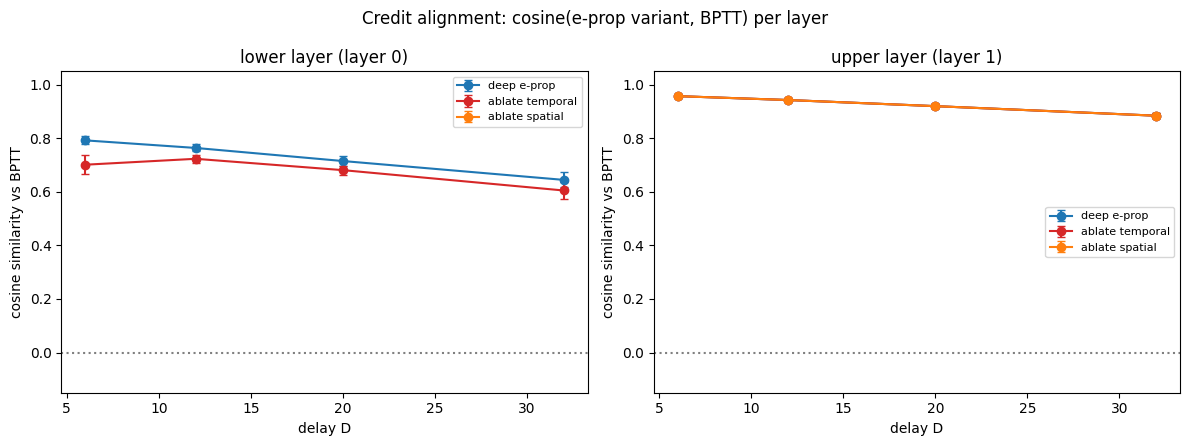

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, layer_key, layer_label in zip(axes, ['lower', 'upper'], ['lower layer (layer 0)', 'upper layer (layer 1)']):
    for meth, label, color in METHODS:
        if meth == 'bptt':
            continue
        mu = [np.nanmean(cos_results[d][meth][layer_key]) for d in DELAYS]
        se = [np.nanstd(cos_results[d][meth][layer_key]) /
              max(1, len(cos_results[d][meth][layer_key])**0.5) for d in DELAYS]
        ax.errorbar(DELAYS, mu, yerr=se, marker='o', color=color, label=label, capsize=3)
    ax.axhline(0, color='gray', ls=':')
    ax.set_xlabel('delay D')
    ax.set_ylabel('cosine similarity vs BPTT')
    ax.set_title(layer_label)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.15, 1.05)

fig.suptitle('Credit alignment: cosine(e-prop variant, BPTT) per layer')
plt.tight_layout()
plt.show()

## 3  Trace-norm evolution over time

We instrument the deep e-prop loop to record, at every timestep:
- `self_norm[t]`  — Frobenius norm of **ε^h** (within-layer self-trace for layer 0)
- `cross_norm[t]` — Frobenius norm of **ε^z** (cross-layer trace: how layer-1 params depend on layer-0 state over time)

For `full` the cross trace should build up during cue windows and **persist** through
the delay. For `ablate_temporal` it should reset each cue (no carry between cues).

In [8]:
def collect_trace_norms(model, inputs, targets, mask, mode='full'):
    """Run deep e-prop and return per-timestep trace norms (no gradient accumulation)."""
    from learning_rules.deep_eprop import compute_deep_eprop_gradients

    L = model.n_layers
    T, B, n_in = inputs.shape
    n = model.n_rec
    dev = inputs.device
    _a = getattr(model, 'alpha', 1.0)
    alphas = [float(_a[l]) for l in range(L)] if isinstance(_a, torch.Tensor) else [float(_a)] * L

    z_temporal_on = (mode != 'ablate_temporal')
    spatial_on    = (mode != 'ablate_spatial')

    W_recs = [model.W_rec(l).detach() for l in range(L)]
    W_ffs  = [model.W_ff(l).detach() for l in range(1, L)]
    W_in_  = model.W_in.detach()
    biases = [model.bias(l).detach() for l in range(L)]
    w_diags = [W_recs[l].diag() for l in range(L)]

    eps_self_rec = [torch.zeros(B, n, n, device=dev) for _ in range(L)]
    eps_self_b   = [torch.zeros(B, n, device=dev) for _ in range(L)]
    eps_self_in  = torch.zeros(B, n, n_in, device=dev)
    eps_self_ff  = [None] + [torch.zeros(B, n, n, device=dev) for _ in range(1, L)]

    # cross-layer trace: how layer 1 depends on layer 0 W_rec
    eps_cross = torch.zeros(B, n, n, n, device=dev)   # shape (B, n_top, n_src, n_src)

    hs = [torch.zeros(B, n, device=dev) for _ in range(L)]
    self_norms, cross_norms = [], []

    for t in range(T):
        x_t = inputs[t]
        hs_prev = [h.clone() for h in hs]
        with torch.no_grad():
            new_hs, tanh_vals = [], []
            for l in range(L):
                inp_l = (x_t @ W_in_.T if l == 0 else new_hs[l-1] @ W_ffs[l-1].T)
                tv = torch.tanh(inp_l + hs_prev[l] @ W_recs[l].T + biases[l])
                h_new = (1 - alphas[l]) * hs_prev[l] + alphas[l] * tv
                tanh_vals.append(tv); new_hs.append(h_new)
            hs = new_hs

        psi  = [1 - tanh_vals[l]**2 for l in range(L)]
        drive = [alphas[l] * psi[l] for l in range(L)]
        carry = [(1 - alphas[l]) + drive[l] * w_diags[l] for l in range(L)]

        # self-trace update (layer 0 W_rec as proxy)
        c0 = carry[0]
        eps_self_rec[0] = (drive[0].unsqueeze(2) * hs_prev[0].unsqueeze(1)
                           + c0.unsqueeze(2) * eps_self_rec[0])

        # cross-layer trace (layer 1 ← layer 0 W_rec)
        J_ff = drive[1].unsqueeze(2) * W_ffs[0]          # (B, n, n)
        sp   = torch.einsum('bpq,bqj->bpqj', J_ff, eps_self_rec[0])  # spatial seed
        if not spatial_on:
            sp = torch.zeros_like(sp)
        c1 = carry[1]
        if z_temporal_on:
            eps_cross = c1[:, :, None, None] * eps_cross + sp
        else:
            eps_cross = sp

        # also update layer 1 self-trace (needed for correct carry, not plotted)
        eps_self_rec[1] = (drive[1].unsqueeze(2) * hs_prev[1].unsqueeze(1)
                           + c1.unsqueeze(2) * eps_self_rec[1])

        self_norms.append(eps_self_rec[0].norm().item() / B**0.5)
        cross_norms.append(eps_cross.norm().item() / B**0.5)

    return np.array(self_norms), np.array(cross_norms)

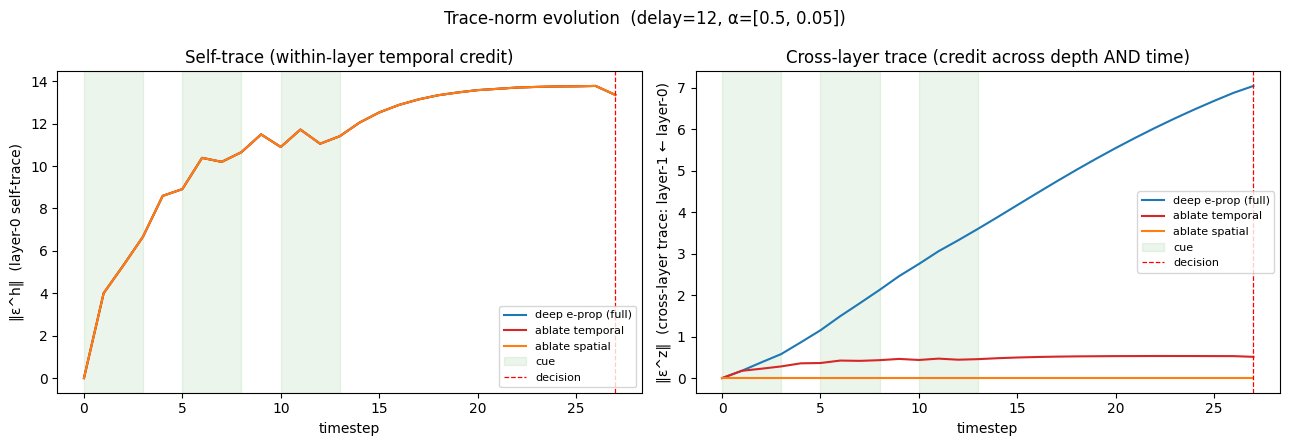

‖ε^z‖ at decision step:
  deep e-prop (full)       : 7.0466
  ablate temporal          : 0.5127
  ablate spatial           : 0.0000


In [9]:
m_trace = new_model(0)
inp_t, tgt_t, msk_t = make_batch(DELAY_MAIN, 42)

trace_modes = [('full', 'deep e-prop (full)', 'C0'),
               ('ablate_temporal', 'ablate temporal', 'C3'),
               ('ablate_spatial',  'ablate spatial',  'C1')]

trace_data = {}
for mode, label, color in trace_modes:
    sn, cn = collect_trace_norms(m_trace, inp_t, tgt_t, msk_t, mode=mode)
    trace_data[mode] = (sn, cn)

# Cue boundaries for shading
cue_dur = TASK_KW['cue_duration']
ici     = TASK_KW['inter_cue_interval']
cue_starts = [c * (cue_dur + ici) for c in range(N_CUES)]
t_ax = np.arange(T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, key, ylabel in zip(axes,
    ['self', 'cross'],
    ['‖ε^h‖  (layer-0 self-trace)', '‖ε^z‖  (cross-layer trace: layer-1 ← layer-0)']):
    for mode, label, color in trace_modes:
        sn, cn = trace_data[mode]
        vals = sn if key == 'self' else cn
        ax.plot(t_ax, vals, color=color, label=label, lw=1.5)
    for cs in cue_starts:
        ax.axvspan(cs, cs + cue_dur, alpha=0.08, color='green', label='cue' if cs == cue_starts[0] else None)
    decision_t = msk_t[:, 0].nonzero(as_tuple=True)[0][0].item()
    ax.axvline(decision_t, color='r', ls='--', lw=0.9, label='decision')
    ax.set_xlabel('timestep'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

axes[0].set_title('Self-trace (within-layer temporal credit)')
axes[1].set_title('Cross-layer trace (credit across depth AND time)')
fig.suptitle(f'Trace-norm evolution  (delay={DELAY_MAIN}, α={ALPHA})')
plt.tight_layout()
plt.show()

# Sanity: cross norm at decision step should be >> 0 for full, reset-ish for ablate_temporal
print(f"‖ε^z‖ at decision step:")
for mode, label, _ in trace_modes:
    _, cn = trace_data[mode]
    print(f"  {label:25s}: {cn[decision_t]:.4f}")

## 4  Cross-temporal credit fraction

Fraction of the lower-layer gradient norm that is **carried by the temporal
component of ε^z** (i.e. lost when we ablate_temporal):

$$\text{xtemp\_share} = \frac{\|g_{\text{full}} - g_{\text{ablate\_temporal}}\|}{\|g_{\text{full}}\|}$$

This should increase with delay.

D=  6  xtemp_share = 0.917 ± 0.007
D= 12  xtemp_share = 0.935 ± 0.015
D= 20  xtemp_share = 0.944 ± 0.011
D= 32  xtemp_share = 0.946 ± 0.003


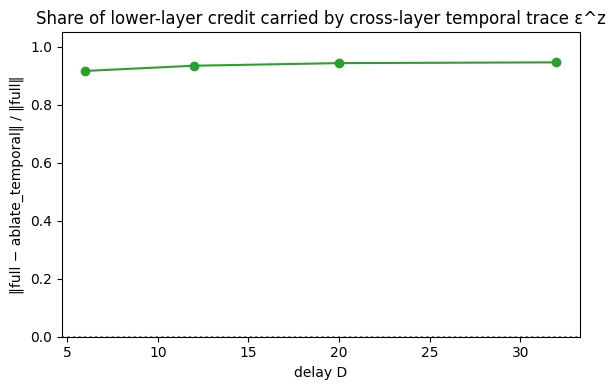

In [10]:
xtemp_shares = {d: [] for d in DELAYS}
for delay in DELAYS:
    for s in range(N_SEEDS_GRAD):
        m = new_model(2000 + s)
        inp, tgt, msk = make_batch(delay, 6000 + s)
        gf = grads_eprop(m, inp, tgt, msk, 'full')
        gt = grads_eprop(m, inp, tgt, msk, 'ablate_temporal')
        vf = flat_grads(gf, LOWER)
        vt = flat_grads(gt, LOWER)
        share = (vf - vt).norm().item() / (vf.norm().item() + 1e-12)
        xtemp_shares[delay].append(share)
    print(f'D={delay:3d}  xtemp_share = {np.mean(xtemp_shares[delay]):.3f} ± {np.std(xtemp_shares[delay]):.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
mu = [np.mean(xtemp_shares[d]) for d in DELAYS]
se = [np.std(xtemp_shares[d]) / max(1, len(xtemp_shares[d])**0.5) for d in DELAYS]
ax.errorbar(DELAYS, mu, yerr=se, marker='o', color='C2', capsize=3)
ax.set_xlabel('delay D'); ax.set_ylabel('‖full − ablate_temporal‖ / ‖full‖')
ax.set_title('Share of lower-layer credit carried by cross-layer temporal trace ε^z')
ax.set_ylim(0, 1.05); ax.axhline(0, color='gray', ls=':')
plt.tight_layout(); plt.show()

## 5  Learning curves

In [11]:
def train_one(method, seed, n_steps=N_STEPS):
    m = new_model(seed)
    curve = [evaluate(m, DELAY_MAIN)]
    for s in range(1, n_steps + 1):
        inp, tgt, msk = make_batch(DELAY_MAIN, 10000 + s)
        if method == 'bptt':
            g = grads_bptt(m, inp, tgt, msk)
        else:
            g = grads_eprop(m, inp, tgt, msk, method)
        apply_gradients(m, g, LR)
        if s % EVAL_EVERY == 0:
            curve.append(evaluate(m, DELAY_MAIN))
    return curve

steps = list(range(0, N_STEPS + 1, EVAL_EVERY))
lc_data = {}
for meth, label, color in METHODS:
    curves = [train_one(meth, seed) for seed in range(N_SEEDS_LC)]
    mat = np.array(curves)
    lc_data[meth] = mat
    print(f'{label:25s}  final={mat[:, -1].mean():.3f} ± {mat[:, -1].std():.3f}')

BPTT                       final=1.000 ± 0.000
deep e-prop                final=0.890 ± 0.019
ablate temporal            final=0.761 ± 0.083
ablate spatial             final=0.762 ± 0.083


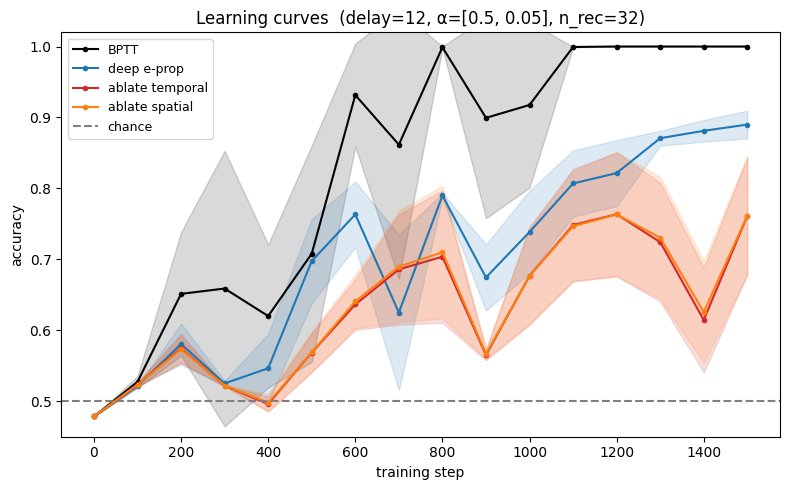


Ordering BPTT >= full > both controls: PASS
  bptt=1.000  full=0.890  ablate_temporal=0.761  ablate_spatial=0.762


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for meth, label, color in METHODS:
    mat = lc_data[meth]
    mu = mat.mean(0); sd = mat.std(0)
    ax.plot(steps, mu, '-o', ms=3, color=color, label=label)
    ax.fill_between(steps, mu - sd, mu + sd, color=color, alpha=0.15)
ax.axhline(0.5, color='gray', ls='--', label='chance')
ax.set_xlabel('training step'); ax.set_ylabel('accuracy')
ax.set_title(f'Learning curves  (delay={DELAY_MAIN}, α={ALPHA}, n_rec={N_REC})')
ax.legend(fontsize=9); ax.set_ylim(0.45, 1.02)
plt.tight_layout(); plt.show()

fin = {m: lc_data[m][:, -1].mean() for m, *_ in METHODS}
ok = fin['bptt'] + 0.02 >= fin['full'] > max(fin['ablate_temporal'], fin['ablate_spatial'])
print(f"\nOrdering BPTT >= full > both controls: {'PASS' if ok else 'FAIL'}")
print('  ' + '  '.join(f"{m}={fin[m]:.3f}" for m, *_ in METHODS))

## 6  Further investigations

Modifications added after the first full run to probe the findings above. Each adds extra training loops, so they are **off by default** (`RUN_S6` / `RUN_S6B`); turn them on and use `SMOKE=False` on Colab.

- **6a — Single-cue ceiling test.** Vary `n_cues` (odd only) and check that both ablations track the analytic single-cue accuracy while `full` stays near BPTT. This *confirms* the shared ~0.76 plateau is a task ceiling, not an implementation artefact. Prediction: ablations follow the theory line (n=3→0.75, n=5→0.69, n=7→0.66); `full` stays high. A clean falsification test — if an ablation sat well *below* the ceiling, that would point to a real bug.
- **6b — Extended delay sweep.** *Train* (not just measure gradients as in §2) across delays beyond §2's range to locate where `full` itself degrades toward the ablation floor as credit must cross more silent time. Run the 6a cell first — 6b reuses `single_cue_ceiling()`.

In [ ]:
# ── 6a  Single-cue ceiling test ───────────────────────────────────────────────
# Confirms the shared ~0.76 ablation plateau is a TASK ceiling (best accuracy from
# reading a single cue and ignoring the count), not an implementation artefact.
# Vary n_cues and check that both ablations track the analytic ceiling while
# `full` stays near BPTT.
from math import comb

def single_cue_ceiling(n):
    """P(one fixed cue == majority of n i.i.d. fair cues), n odd.

    Fix one cue = side A; the majority is A iff at least floor(n/2) of the other
    n-1 cues are also A. This is the best accuracy from reading a single cue.
        n=3 -> 0.750,  n=5 -> 0.6875,  n=7 -> 0.6563
    """
    k = n // 2
    return sum(comb(n - 1, j) for j in range(k, n)) / 2 ** (n - 1)

RUN_S6 = False         # set True to run (heavy: trains a fresh net per n_cues/method/seed)

if RUN_S6:
    NCUES_SWEEP = [3, 5, 7] if not SMOKE else [3, 5]   # odd only (avoids ties)
    S6_METHODS = [('bptt', 'BPTT', 'k'), ('full', 'deep e-prop', 'C0'),
                  ('ablate_temporal', 'ablate temporal', 'C3'),
                  ('ablate_spatial', 'ablate spatial', 'C1')]

    def train_ncues(method, seed, n_cues, n_steps):
        torch.manual_seed(seed)
        m = DeepRNN(5, N_REC, 2, n_layers=2, alpha=ALPHA).to(DEVICE)
        for s in range(1, n_steps + 1):
            inp, tgt, msk = generate_batch(BATCH, n_cues=n_cues, delay=DELAY_MAIN,
                                           seed=10000 + s, device=DEVICE, **TASK_KW)
            g = (grads_bptt(m, inp, tgt, msk) if method == 'bptt'
                 else grads_eprop(m, inp, tgt, msk, method))
            apply_gradients(m, g, LR)
        inp, tgt, msk = generate_batch(256, n_cues=n_cues, delay=DELAY_MAIN,
                                       seed=90000, device=DEVICE, **TASK_KW)
        with torch.no_grad():
            out, _ = m(inp)
        return task_accuracy(out, tgt, msk)

    s6 = {meth: [] for meth, *_ in S6_METHODS}
    for nc in NCUES_SWEEP:
        for meth, *_ in S6_METHODS:
            accs = [train_ncues(meth, seed, nc, N_STEPS) for seed in range(N_SEEDS_LC)]
            s6[meth].append((float(np.mean(accs)), float(np.std(accs))))
        print(f'n_cues={nc}  ceiling={single_cue_ceiling(nc):.3f}  ' +
              '  '.join(f"{meth}={s6[meth][-1][0]:.3f}" for meth, *_ in S6_METHODS))

    fig, ax = plt.subplots(figsize=(7, 4.6))
    for meth, label, color in S6_METHODS:
        mu = [v[0] for v in s6[meth]]; sd = [v[1] for v in s6[meth]]
        ax.errorbar(NCUES_SWEEP, mu, yerr=sd, marker='o', color=color, label=label, capsize=3)
    ax.plot(NCUES_SWEEP, [single_cue_ceiling(n) for n in NCUES_SWEEP],
            'k:', marker='s', label='single-cue ceiling (theory)')
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='chance')
    ax.set_xlabel('n_cues'); ax.set_ylabel('final accuracy')
    ax.set_title('Single-cue ceiling test: do ablations track the theory line?')
    ax.set_xticks(NCUES_SWEEP); ax.legend(fontsize=8); ax.set_ylim(0.45, 1.02)
    plt.tight_layout(); plt.show()
else:
    print('6a skipped (set RUN_S6=True). Predicted single-cue ceilings:')
    for n in (3, 5, 7):
        print(f'  n_cues={n}: {single_cue_ceiling(n):.4f}')

In [ ]:
# ── 6b  Extended delay sweep (train, not just gradients) ──────────────────────
# Where does `full` itself start to degrade toward the ablation floor as credit
# must cross more silent time? §2 only measured gradient cosines; here we TRAIN.
# Depends on single_cue_ceiling() defined in the 6a cell above (run it first).
RUN_S6B = False        # set True to run (heavy: trains a fresh net per delay/method/seed)

if RUN_S6B:
    DELAY_SWEEP = [8, 16, 24, 32, 48] if not SMOKE else [8, 16]
    B_METHODS = [('bptt', 'BPTT', 'k'), ('full', 'deep e-prop', 'C0'),
                 ('ablate_temporal', 'ablate temporal', 'C3'),
                 ('ablate_spatial', 'ablate spatial', 'C1')]

    def train_delay(method, seed, delay, n_steps):
        torch.manual_seed(seed)
        m = DeepRNN(5, N_REC, 2, n_layers=2, alpha=ALPHA).to(DEVICE)
        for s in range(1, n_steps + 1):
            inp, tgt, msk = generate_batch(BATCH, n_cues=N_CUES, delay=delay,
                                           seed=10000 + s, device=DEVICE, **TASK_KW)
            g = (grads_bptt(m, inp, tgt, msk) if method == 'bptt'
                 else grads_eprop(m, inp, tgt, msk, method))
            apply_gradients(m, g, LR)
        inp, tgt, msk = generate_batch(256, n_cues=N_CUES, delay=delay,
                                       seed=90000, device=DEVICE, **TASK_KW)
        with torch.no_grad():
            out, _ = m(inp)
        return task_accuracy(out, tgt, msk)

    sweep = {meth: [] for meth, *_ in B_METHODS}
    for d in DELAY_SWEEP:
        for meth, *_ in B_METHODS:
            accs = [train_delay(meth, seed, d, N_STEPS) for seed in range(N_SEEDS_LC)]
            sweep[meth].append((float(np.mean(accs)), float(np.std(accs))))
        print(f'delay={d:3d}  ' + '  '.join(
            f"{meth}={sweep[meth][-1][0]:.3f}" for meth, *_ in B_METHODS))

    fig, ax = plt.subplots(figsize=(7, 4.6))
    for meth, label, color in B_METHODS:
        mu = [v[0] for v in sweep[meth]]; sd = [v[1] for v in sweep[meth]]
        ax.errorbar(DELAY_SWEEP, mu, yerr=sd, marker='o', color=color, label=label, capsize=3)
    ax.axhline(single_cue_ceiling(N_CUES), color='gray', ls=':', label='single-cue ceiling')
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='chance')
    ax.set_xlabel('delay D'); ax.set_ylabel('final accuracy')
    ax.set_title('Extended delay sweep — where does full e-prop degrade?')
    ax.legend(fontsize=8); ax.set_ylim(0.45, 1.02)
    plt.tight_layout(); plt.show()
else:
    print('6b skipped (set RUN_S6B=True).')